In [22]:
#importando bibliotecas utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import random

warnings.filterwarnings('ignore')

# Imports de ML
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    RandomizedSearchCV, learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    recall_score, precision_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    matthews_corrcoef
)
from scipy import stats

print("✅ Todas as bibliotecas carregadas com sucesso!")

✅ Todas as bibliotecas carregadas com sucesso!


In [23]:
#CARGA DE DADOS
url_dataset = "https://raw.githubusercontent.com/danielmagliano2002/dados-mvp-churn/refs/heads/main/customer_churn_dataset-testing-master.csv"

def carregar_dados(url):
    """Carrega o dataset com validações básicas de integridade."""
    try:
        df = pd.read_csv(url, sep=',')
        print(f"✅ Dataset carregado! Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas.")
        return df
    except Exception as e:
        print(f"❌ Erro ao carregar: {e}")
        return None

df_churn = carregar_dados(url_dataset)

# --- [MELHORIA #1] Relatório de qualidade dos dados ---
print("\n" + "="*60)
print("RELATÓRIO DE QUALIDADE DOS DADOS")
print("="*60)

print("\n📋 Tipos de dados por coluna:")
print(df_churn.dtypes)

print("\n📋 Valores nulos por coluna:")
nulos = df_churn.isnull().sum()
pct_nulos = (nulos / len(df_churn) * 100).round(2)
df_qualidade = pd.DataFrame({'Nulos': nulos, '% Nulos': pct_nulos})
print(df_qualidade[df_qualidade['Nulos'] > 0])

print("\n📋 Duplicatas:")
n_dup = df_churn.duplicated().sum()
print(f"  Linhas duplicadas: {n_dup} ({n_dup/len(df_churn)*100:.2f}%)")
if n_dup > 0:
    df_churn = df_churn.drop_duplicates()
    print(f"  ✅ Duplicatas removidas. Novo shape: {df_churn.shape}")

# --- [MELHORIA #2] Análise do balanceamento da variável alvo ---
coluna_alvo = 'Churn'
print(f"\n📋 Distribuição da variável alvo '{coluna_alvo}':")
contagem = df_churn[coluna_alvo].value_counts()
pct = df_churn[coluna_alvo].value_counts(normalize=True) * 100
df_balanco = pd.DataFrame({'Contagem': contagem, '%': pct.round(2)})
print(df_balanco)

ratio = contagem.min() / contagem.max()
if ratio < 0.3:
    print(f"\n⚠️  ALERTA: Classes desbalanceadas! Ratio minoritária/majoritária = {ratio:.2f}")
    print("   Considere: class_weight='balanced', SMOTE ou ajuste de threshold.")
else:
    print(f"\n✅ Classes razoavelmente balanceadas (ratio = {ratio:.2f})")

✅ Dataset carregado! Dimensões: 64374 linhas × 12 colunas.

RELATÓRIO DE QUALIDADE DOS DADOS

📋 Tipos de dados por coluna:
CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object

📋 Valores nulos por coluna:
Empty DataFrame
Columns: [Nulos, % Nulos]
Index: []

📋 Duplicatas:
  Linhas duplicadas: 0 (0.00%)

📋 Distribuição da variável alvo 'Churn':
       Contagem      %
Churn                 
0         33881  52.63
1         30493  47.37

✅ Classes razoavelmente balanceadas (ratio = 0.90)



ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

📊 Estatísticas descritivas (numéricas):


,count,mean,std,min,25%,50%,75%,max
CustomerID,64374.0,32187.500000,18583.317451,1.0,16094.25,32187.5,48280.75,64374.0
Age,64374.0,41.970982,13.924911,18.0,30.00,42.0,54.00,65.0
Tenure,64374.0,31.994827,17.098234,1.0,18.00,33.0,47.00,60.0
Usage Frequency,64374.0,15.080234,8.816470,1.0,7.00,15.0,23.00,30.0
Support Calls,64374.0,5.400690,3.114005,0.0,3.00,6.0,8.00,10.0
Payment Delay,64374.0,17.133952,8.852211,0.0,10.00,19.0,25.00,30.0
Total Spend,64374.0,541.023379,260.874809,100.0,313.00,534.0,768.00,1000.0
Last Interaction,64374.0,15.498850,8.638436,1.0,8.00,15.0,23.00,30.0
Churn,64374.0,0.473685,0.499311,0.0,0.00,0.0,1.00,1.0



📋 Detecção de Outliers (Z-Score > 3):

📋 Correlação de Pearson das variáveis numéricas com o Churn:
Payment Delay       0.5574
CustomerID          0.5298
Support Calls       0.3046
Tenure              0.1953
Age                 0.0635
Last Interaction   -0.0028
Total Spend        -0.0789
Usage Frequency    -0.1151
dtype: float64


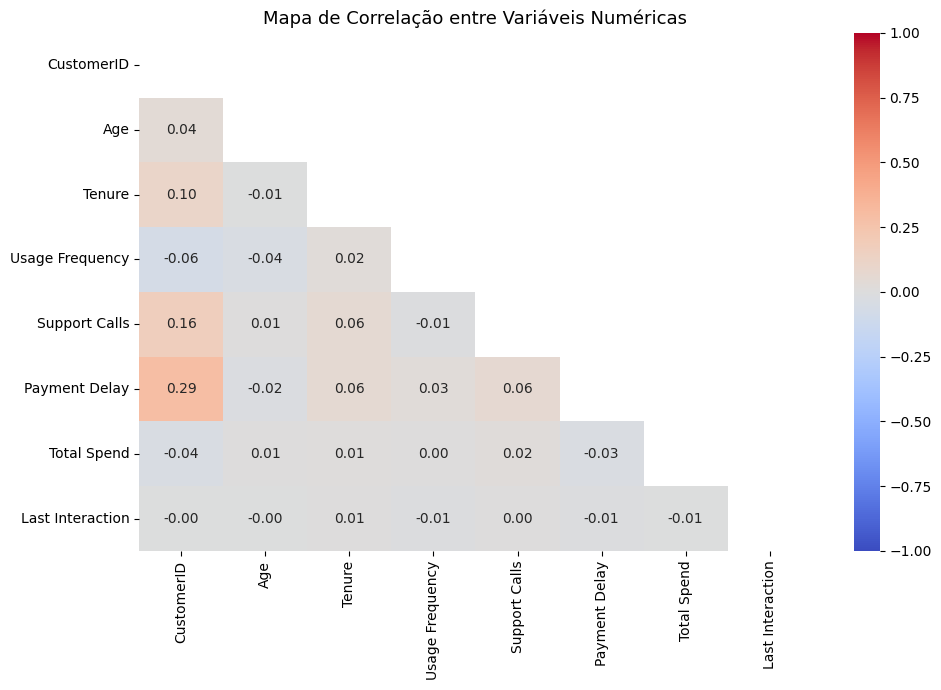

In [24]:
print("\n" + "="*60)
print("ANÁLISE EXPLORATÓRIA DE DADOS (EDA)")
print("="*60)

print("\n📊 Estatísticas descritivas (numéricas):")
display(df_churn.describe().T)

# --- [MELHORIA #3] Detecção de outliers com Z-Score e IQR ---
print("\n📋 Detecção de Outliers (Z-Score > 3):")
colunas_num_eda = df_churn.select_dtypes(include=['int64', 'float64']).columns.drop(coluna_alvo, errors='ignore')
for col in colunas_num_eda:
    z_scores = np.abs(stats.zscore(df_churn[col].dropna()))
    n_outliers = (z_scores > 3).sum()
    if n_outliers > 0:
        print(f"  {col}: {n_outliers} outliers ({n_outliers/len(df_churn)*100:.1f}%)")

# --- [MELHORIA #4] Correlação com a variável alvo ---
print("\n📋 Correlação de Pearson das variáveis numéricas com o Churn:")
corr_alvo = df_churn[colunas_num_eda].corrwith(df_churn[coluna_alvo]).sort_values(ascending=False)
print(corr_alvo.round(4))

# Heatmap de correlação
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(df_churn[colunas_num_eda].corr(), dtype=bool))
sns.heatmap(df_churn[colunas_num_eda].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, center=0)
plt.title('Mapa de Correlação entre Variáveis Numéricas', fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
print("\n" + "="*60)
print("SEPARAÇÃO DE DADOS")
print("="*60)

# Removendo variáveis tóxicas (identificadores + leakage confirmado anteriormente)
colunas_toxicas = ['CustomerID', 'Payment Delay']
colunas_para_remover = [coluna_alvo] + [c for c in colunas_toxicas if c in df_churn.columns]

X = df_churn.drop(columns=colunas_para_remover)
y = df_churn[coluna_alvo]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"✅ Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print(f"   Proporção de Churn no treino: {y_train.mean():.4f}")
print(f"   Proporção de Churn no teste:  {y_test.mean():.4f}")


SEPARAÇÃO DE DADOS
✅ Treino: 45061 amostras | Teste: 19313 amostras
   Proporção de Churn no treino: 0.4737
   Proporção de Churn no teste:  0.4737


In [26]:
#pre processamento com pipeline
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()

pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipeline_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

pre_processador = ColumnTransformer(transformers=[
    ('num', pipeline_numerico, num_cols),
    ('cat', pipeline_categorico, cat_cols)
])

In [27]:
print("\n" + "="*60)
print("TREINAMENTO E VALIDAÇÃO CRUZADA (5 FOLDS ESTRATIFICADOS)")
print("="*60)

# --- [MELHORIA #5] Adiciona GradientBoosting como terceiro candidato ---
# --- [MELHORIA #6] Usa StratifiedKFold explícito para garantir estratificação ---
# --- [MELHORIA #7] Avalia múltiplas métricas na validação cruzada ---

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    'Regressão Logística': Pipeline(steps=[
        ('pre', pre_processador),
        ('clf', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline(steps=[
        ('pre', pre_processador),
        ('clf', RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'))
    ]),
    'Gradient Boosting': Pipeline(steps=[
        ('pre', pre_processador),
        ('clf', GradientBoostingClassifier(random_state=42, n_estimators=100))
    ])
}

resultados_cv = {}
metricas_avaliar = ['accuracy', 'recall', 'precision', 'f1', 'roc_auc']

for nome, modelo in modelos.items():
    print(f"\n🔄 Avaliando: {nome}")
    scores = {}
    for metrica in metricas_avaliar:
        cv_score = cross_val_score(modelo, X_train, y_train, cv=cv_strategy, scoring=metrica)
        scores[metrica] = {'media': cv_score.mean(), 'std': cv_score.std()}
        print(f"   {metrica:12s}: {cv_score.mean():.4f} ± {cv_score.std():.4f}")
    resultados_cv[nome] = scores

# --- [MELHORIA #8] Tabela comparativa visual dos modelos ---
print("\n\n📊 TABELA COMPARATIVA — VALIDAÇÃO CRUZADA")
linhas = []
for nome, scores in resultados_cv.items():
    linha = {'Modelo': nome}
    for m in metricas_avaliar:
        linha[m.capitalize()] = f"{scores[m]['media']:.4f} ± {scores[m]['std']:.4f}"
    linhas.append(linha)
df_comparativo = pd.DataFrame(linhas).set_index('Modelo')
display(df_comparativo)


TREINAMENTO E VALIDAÇÃO CRUZADA (5 FOLDS ESTRATIFICADOS)

🔄 Avaliando: Regressão Logística
   accuracy    : 0.6847 ± 0.0036
   recall      : 0.6940 ± 0.0029
   precision   : 0.6587 ± 0.0045
   f1          : 0.6759 ± 0.0031
   roc_auc     : 0.7495 ± 0.0043

🔄 Avaliando: Random Forest
   accuracy    : 0.7764 ± 0.0024
   recall      : 0.8961 ± 0.0054
   precision   : 0.7088 ± 0.0030
   f1          : 0.7915 ± 0.0022
   roc_auc     : 0.8462 ± 0.0013

🔄 Avaliando: Gradient Boosting
   accuracy    : 0.7712 ± 0.0042
   recall      : 0.8334 ± 0.0123
   precision   : 0.7249 ± 0.0024
   f1          : 0.7753 ± 0.0056
   roc_auc     : 0.8528 ± 0.0032


📊 TABELA COMPARATIVA — VALIDAÇÃO CRUZADA


,Accuracy,Recall,Precision,F1,Roc_auc
Modelo,,,,,
Regressão Logística,0.6847 ± 0.0036,0.6940 ± 0.0029,0.6587 ± 0.0045,0.6759 ± 0.0031,0.7495 ± 0.0043
Random Forest,0.7764 ± 0.0024,0.8961 ± 0.0054,0.7088 ± 0.0030,0.7915 ± 0.0022,0.8462 ± 0.0013
Gradient Boosting,0.7712 ± 0.0042,0.8334 ± 0.0123,0.7249 ± 0.0024,0.7753 ± 0.0056,0.8528 ± 0.0032


In [28]:
print("\n" + "="*60)
print("OTIMIZAÇÃO DO MELHOR MODELO (RandomizedSearchCV)")
print("="*60)

# Random Forest como vencedor (critério: AUC)
pipeline_rf = modelos['Random Forest']

parametros_busca = {
    'clf__n_estimators': [100, 200, 300, 500],
    'clf__max_depth': [None, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2']   # [MELHORIA #9] parâmetro adicional
}

otimizador = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=parametros_busca,
    n_iter=20,          # [MELHORIA #10] Aumentado de 10 para 20 iterações
    cv=cv_strategy,
    scoring='roc_auc',  # [MELHORIA #11] Otimiza AUC em vez de recall isolado
    random_state=42,
    n_jobs=-1,
    verbose=1
)

otimizador.fit(X_train, y_train)
melhor_modelo = otimizador.best_estimator_

print(f"\n✅ Melhores hiperparâmetros: {otimizador.best_params_}")
print(f"   Melhor AUC na CV: {otimizador.best_score_:.4f}")


OTIMIZAÇÃO DO MELHOR MODELO (RandomizedSearchCV)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Melhores hiperparâmetros: {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 10}
   Melhor AUC na CV: 0.8526



AVALIAÇÃO FINAL — BASE DE TESTE (HOLD-OUT 30%)

Métrica                             Valor
------------------------------------------
Acurácia                           0.7874
Precisão (Churn=1)                 0.6924
Recall (Churn=1)                   0.9918
F1-Score                           0.8155
ROC-AUC                            0.8549
Average Precision (PR-AUC)         0.8108
Matthews Corr. Coef. (MCC)         0.6364

📋 Relatório de Classificação Completo:
              precision    recall  f1-score   support

Não Cancelou       0.99      0.60      0.75     10165
    Cancelou       0.69      0.99      0.82      9148

    accuracy                           0.79     19313
   macro avg       0.84      0.80      0.78     19313
weighted avg       0.85      0.79      0.78     19313



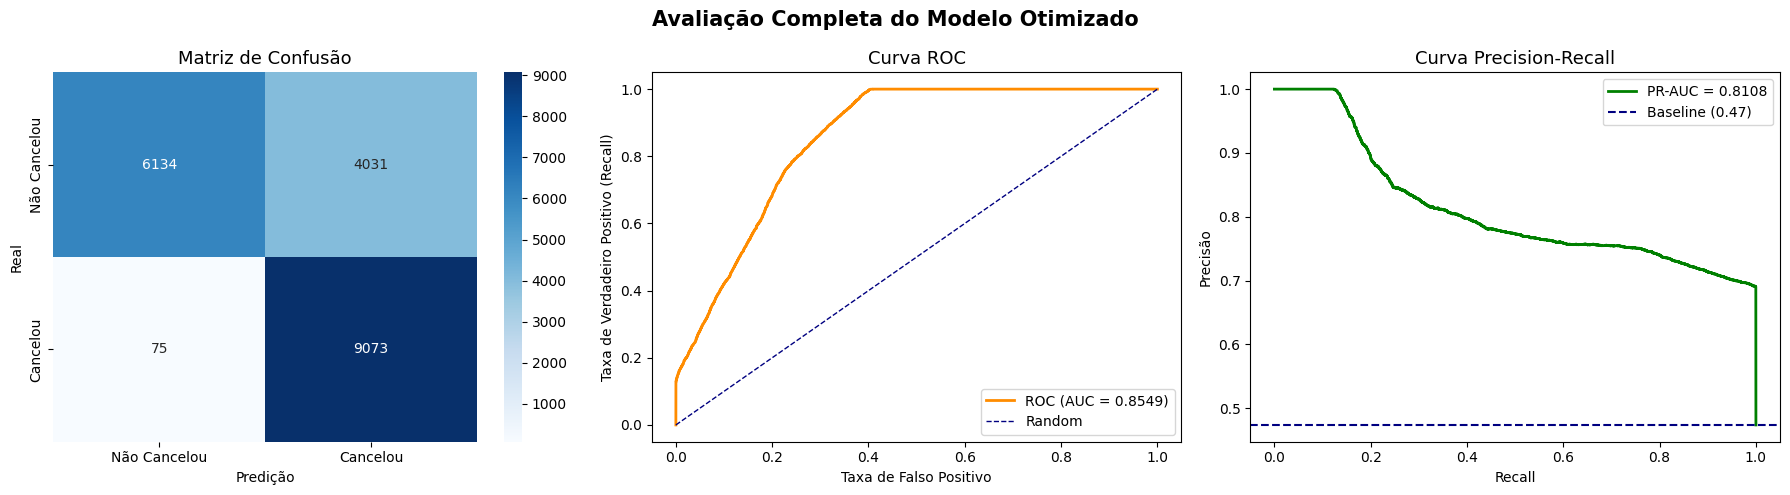

In [29]:
print("\n" + "="*60)
print("AVALIAÇÃO FINAL — BASE DE TESTE (HOLD-OUT 30%)")
print("="*60)

y_pred = melhor_modelo.predict(X_test)
y_prob = melhor_modelo.predict_proba(X_test)[:, 1]

# --- [MELHORIA #12] Suite completa de métricas ---
acc  = accuracy_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)
ap   = average_precision_score(y_test, y_prob)
mcc  = matthews_corrcoef(y_test, y_pred)  # Matthews Correlation Coefficient

print(f"\n{'Métrica':<30} {'Valor':>10}")
print("-" * 42)
print(f"{'Acurácia':<30} {acc:>10.4f}")
print(f"{'Precisão (Churn=1)':<30} {prec:>10.4f}")
print(f"{'Recall (Churn=1)':<30} {rec:>10.4f}")
print(f"{'F1-Score':<30} {f1:>10.4f}")
print(f"{'ROC-AUC':<30} {auc:>10.4f}")
print(f"{'Average Precision (PR-AUC)':<30} {ap:>10.4f}")
print(f"{'Matthews Corr. Coef. (MCC)':<30} {mcc:>10.4f}")

print("\n📋 Relatório de Classificação Completo:")
print(classification_report(y_test, y_pred, target_names=['Não Cancelou', 'Cancelou']))

# --- [MELHORIA #13] Gráficos de avaliação combinados ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Não Cancelou', 'Cancelou'],
            yticklabels=['Não Cancelou', 'Cancelou'])
axes[0].set_title('Matriz de Confusão', fontsize=13)
axes[0].set_xlabel('Predição')
axes[0].set_ylabel('Real')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random')
axes[1].set_xlabel('Taxa de Falso Positivo')
axes[1].set_ylabel('Taxa de Verdadeiro Positivo (Recall)')
axes[1].set_title('Curva ROC', fontsize=13)
axes[1].legend(loc='lower right')

# 3. Curva Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
axes[2].plot(recall_curve, precision_curve, color='green', lw=2, label=f'PR-AUC = {ap:.4f}')
axes[2].axhline(y=y_test.mean(), color='navy', linestyle='--', label=f'Baseline ({y_test.mean():.2f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precisão')
axes[2].set_title('Curva Precision-Recall', fontsize=13)
axes[2].legend(loc='upper right')

plt.suptitle('Avaliação Completa do Modelo Otimizado', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


DIAGNÓSTICO DE OVERFITTING — LEARNING CURVE


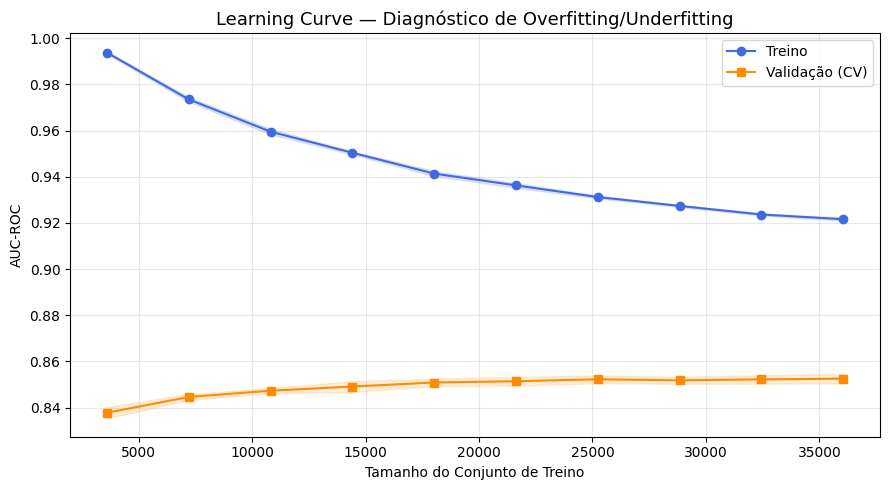


📋 Gap Treino vs Validação (AUC): 0.0691
   ⚠️  Gap > 5% → indício de overfitting. Recomenda-se regularização adicional.


In [30]:
print("\n" + "="*60)
print("DIAGNÓSTICO DE OVERFITTING — LEARNING CURVE")
print("="*60)

# --- [MELHORIA #14] Learning Curve para diagnóstico visual de overfitting ---
train_sizes, train_scores, val_scores = learning_curve(
    melhor_modelo, X_train, y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='royalblue', label='Treino')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='royalblue')
plt.plot(train_sizes, val_mean, 's-', color='darkorange', label='Validação (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='darkorange')
plt.xlabel('Tamanho do Conjunto de Treino')
plt.ylabel('AUC-ROC')
plt.title('Learning Curve — Diagnóstico de Overfitting/Underfitting', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gap = (train_mean[-1] - val_mean[-1])
print(f"\n📋 Gap Treino vs Validação (AUC): {gap:.4f}")
if gap > 0.05:
    print(f"   ⚠️  Gap > 5% → indício de overfitting. Recomenda-se regularização adicional.")
else:
    print(f"   ✅ Gap ≤ 5% → modelo generaliza bem.")


IMPORTÂNCIA DAS VARIÁVEIS — MODELO FINAL

📋 7 variáveis explicam 90% da importância do modelo.


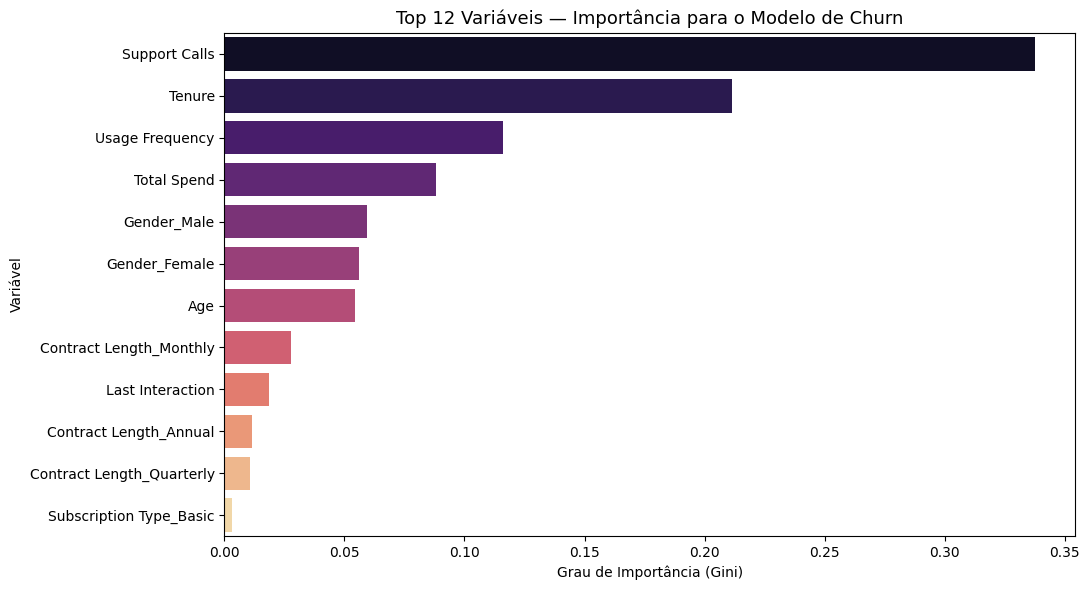

,Variável,Importância,Importância Acumulada
3,Support Calls,0.337446,0.337446
1,Tenure,0.211303,0.548749
2,Usage Frequency,0.116102,0.664850
4,Total Spend,0.088322,0.753173
7,Gender_Male,0.059331,0.812503
6,Gender_Female,0.056135,0.868639
0,Age,0.054238,0.922876
12,Contract Length_Monthly,0.027781,0.950658
5,Last Interaction,0.018750,0.969407
11,Contract Length_Annual,0.011316,0.980724


In [32]:
print("\n" + "="*60)
print("IMPORTÂNCIA DAS VARIÁVEIS — MODELO FINAL")
print("="*60)

# Reconstruindo nomes das colunas após OHE
# Acessando o pre_processador já ajustado dentro do melhor_modelo
nomes_cat = melhor_modelo.named_steps['pre'].named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)
colunas_finais = num_cols + list(nomes_cat)

importancias = melhor_modelo.named_steps['clf'].feature_importances_
df_imp = pd.DataFrame({
    'Variável': colunas_finais,
    'Importância': importancias
}).sort_values(by='Importância', ascending=False)

# --- [MELHORIA #15] Importância acumulada (explicabilidade do modelo) ---
df_imp['Importância Acumulada'] = df_imp['Importância'].cumsum()
n_90pct = (df_imp['Importância Acumulada'] <= 0.90).sum() + 1
print(f"\n📋 {n_90pct} variáveis explicam 90% da importância do modelo.")

plt.figure(figsize=(11, 6))
sns.barplot(x='Importância', y='Variável', data=df_imp.head(12), palette='magma')
plt.title('Top 12 Variáveis — Importância para o Modelo de Churn', fontsize=13)
plt.xlabel('Grau de Importância (Gini)')
plt.tight_layout()
plt.show()

display(df_imp.head(10))

In [33]:
print("\n" + "="*60)
print("VALIDAÇÃO ESTATÍSTICA — TESTES DE HIPÓTESE")
print("="*60)

# --- [MELHORIA #16] Testes de Mann-Whitney para variáveis numéricas ---
print("\n📋 Teste de Mann-Whitney U (variáveis numéricas vs. Churn):")
print("   H₀: distribuições iguais nos grupos Churn=0 e Churn=1")
print(f"   {'Variável':<30} {'U Statistic':>14} {'p-value':>12} {'Significativo?':>16}")
print("   " + "-"*76)

grupo_0 = df_churn[df_churn[coluna_alvo] == 0]
grupo_1 = df_churn[df_churn[coluna_alvo] == 1]

for col in num_cols:
    if col in df_churn.columns:
        u_stat, p_val = stats.mannwhitneyu(
            grupo_0[col].dropna(),
            grupo_1[col].dropna(),
            alternative='two-sided'
        )
        sig = "✅ Sim (α=0.05)" if p_val < 0.05 else "❌ Não"
        print(f"   {col:<30} {u_stat:>14.1f} {p_val:>12.4f} {sig:>16}")

# --- [MELHORIA #17] Teste Qui-Quadrado para variáveis categóricas ---
print("\n📋 Teste Qui-Quadrado (variáveis categóricas vs. Churn):")
print("   H₀: variável categórica é independente do Churn")
print(f"   {'Variável':<30} {'Chi²':>10} {'p-value':>12} {'Significativo?':>16}")
print("   " + "-"*72)

for col in cat_cols:
    if col in df_churn.columns:
        tabela = pd.crosstab(df_churn[col], df_churn[coluna_alvo])
        chi2, p, dof, _ = stats.chi2_contingency(tabela)
        sig = "✅ Sim (α=0.05)" if p < 0.05 else "❌ Não"
        print(f"   {col:<30} {chi2:>10.2f} {p:>12.4f} {sig:>16}")



VALIDAÇÃO ESTATÍSTICA — TESTES DE HIPÓTESE

📋 Teste de Mann-Whitney U (variáveis numéricas vs. Churn):
   H₀: distribuições iguais nos grupos Churn=0 e Churn=1
   Variável                          U Statistic      p-value   Significativo?
   ----------------------------------------------------------------------------
   Age                               478461491.5       0.0000   ✅ Sim (α=0.05)
   Tenure                            401523759.5       0.0000   ✅ Sim (α=0.05)
   Usage Frequency                   586505669.0       0.0000   ✅ Sim (α=0.05)
   Support Calls                     338673868.0       0.0000   ✅ Sim (α=0.05)
   Total Spend                       563703844.5       0.0000   ✅ Sim (α=0.05)
   Last Interaction                  518255182.5       0.4730            ❌ Não

📋 Teste Qui-Quadrado (variáveis categóricas vs. Churn):
   H₀: variável categórica é independente do Churn
   Variável                             Chi²      p-value   Significativo?
   --------------------


ANÁLISE DE THRESHOLD — PONTO DE CORTE ÓTIMO


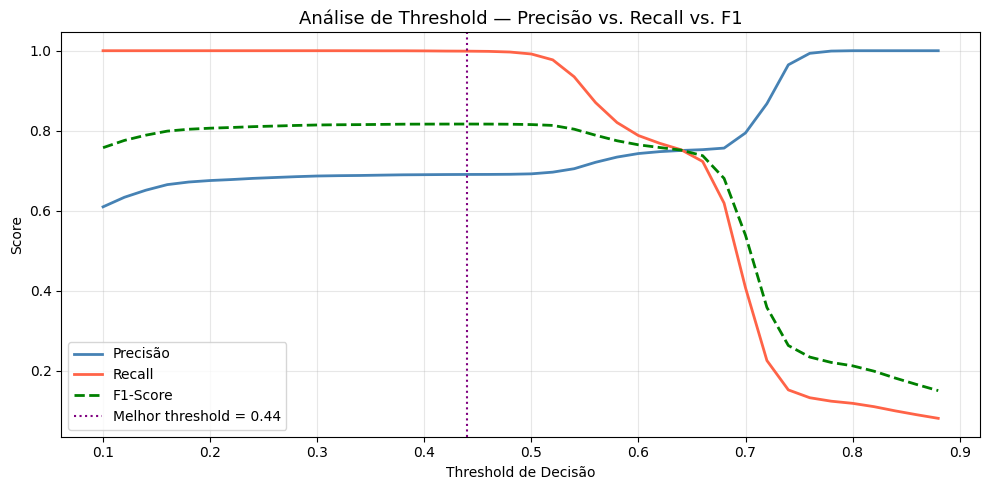


📋 Threshold padrão (0.50): F1 = 0.8155
   Threshold ótimo (0.44): F1 = 0.8168

📋 Métricas com threshold ótimo (0.44):
   Recall:    0.9989
   Precisão:  0.6909
   F1-Score:  0.8168


In [34]:
print("\n" + "="*60)
print("ANÁLISE DE THRESHOLD — PONTO DE CORTE ÓTIMO")
print("="*60)

# --- [MELHORIA #18] Análise de threshold para maximizar F1 ou Recall ---
thresholds = np.arange(0.1, 0.9, 0.02)
resultados_thresh = []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    resultados_thresh.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall': recall_score(y_test, y_pred_t, zero_division=0),
        'F1': f1_score(y_test, y_pred_t, zero_division=0)
    })

df_thresh = pd.DataFrame(resultados_thresh)
idx_melhor_f1 = df_thresh['F1'].idxmax()
melhor_thresh = df_thresh.loc[idx_melhor_f1, 'Threshold']
melhor_f1_val = df_thresh.loc[idx_melhor_f1, 'F1']

plt.figure(figsize=(10, 5))
plt.plot(df_thresh['Threshold'], df_thresh['Precision'], label='Precisão', color='steelblue', lw=2)
plt.plot(df_thresh['Threshold'], df_thresh['Recall'],    label='Recall',   color='tomato',   lw=2)
plt.plot(df_thresh['Threshold'], df_thresh['F1'],        label='F1-Score', color='green',    lw=2, linestyle='--')
plt.axvline(melhor_thresh, color='purple', linestyle=':', label=f'Melhor threshold = {melhor_thresh:.2f}')
plt.xlabel('Threshold de Decisão')
plt.ylabel('Score')
plt.title('Análise de Threshold — Precisão vs. Recall vs. F1', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📋 Threshold padrão (0.50): F1 = {f1_score(y_test, y_pred):.4f}")
print(f"   Threshold ótimo ({melhor_thresh:.2f}): F1 = {melhor_f1_val:.4f}")

# Reaplicando com threshold ótimo
y_pred_otimizado = (y_prob >= melhor_thresh).astype(int)
print(f"\n📋 Métricas com threshold ótimo ({melhor_thresh:.2f}):")
print(f"   Recall:    {recall_score(y_test, y_pred_otimizado):.4f}")
print(f"   Precisão:  {precision_score(y_test, y_pred_otimizado):.4f}")
print(f"   F1-Score:  {f1_score(y_test, y_pred_otimizado):.4f}")

In [35]:
print("\n" + "="*60)
print("EXPORTAÇÃO DO MODELO — DEPLOY DO MVP")
print("="*60)

# --- [MELHORIA #19] Salva modelo + metadados juntos para rastreabilidade ---
artefato = {
    'modelo': melhor_modelo,
    'threshold_otimo': melhor_thresh,
    'metricas_teste': {
        'acuracia': acc,
        'recall': rec,
        'precisao': prec,
        'f1': f1,
        'roc_auc': auc,
        'pr_auc': ap,
        'mcc': mcc
    },
    'features_utilizadas': list(X.columns),
    'colunas_removidas': colunas_toxicas,
    'random_state': 42,
    'versao': '2.0_incrementado'
}

nome_arquivo = 'pipeline_churn_rf_v2.pkl'
joblib.dump(artefato, nome_arquivo)
print(f"✅ Modelo + metadados salvos em '{nome_arquivo}'")



EXPORTAÇÃO DO MODELO — DEPLOY DO MVP
✅ Modelo + metadados salvos em 'pipeline_churn_rf_v2.pkl'


In [36]:
print("\n" + "="*60)
print("SIMULAÇÃO — PREDIÇÃO EM PRODUÇÃO")
print("="*60)

cliente_sorteado = X_test.sample(1, random_state=random.randint(1, 999))

print("📊 Dados do cliente analisado:")
display(cliente_sorteado)

prob_churn = melhor_modelo.predict_proba(cliente_sorteado)[0][1]
previsao = int(prob_churn >= melhor_thresh)

print("\n🔮 VEREDITO DO MODELO:")
if previsao == 1:
    print(f"  ⚠️  ALERTA: Alto risco de Churn!")
    print(f"  Probabilidade: {prob_churn * 100:.1f}%")
    if prob_churn >= 0.8:
        print("  Ação: Intervenção URGENTE — oferta personalizada imediata.")
    else:
        print("  Ação: Campanha de retenção preventiva.")
else:
    print(f"  ✅ CLIENTE SEGURO — Baixo risco de evasão.")
    print(f"  Probabilidade de Churn: {prob_churn * 100:.1f}%")
    print("  Ação: Manutenção das réguas de relacionamento padrão.")

print("\n" + "="*60)
print("✅ PIPELINE COMPLETO CONCLUÍDO — MVP v2.0")
print("="*60)


SIMULAÇÃO — PREDIÇÃO EM PRODUÇÃO
📊 Dados do cliente analisado:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Subscription Type,Contract Length,Total Spend,Last Interaction
22076,21,Male,53,25,10,Standard,Quarterly,557,21



🔮 VEREDITO DO MODELO:
  ⚠️  ALERTA: Alto risco de Churn!
  Probabilidade: 66.9%
  Ação: Campanha de retenção preventiva.

✅ PIPELINE COMPLETO CONCLUÍDO — MVP v2.0
